In [1]:
import pandas as pd
import numpy as np
from numpy import pi as π, sin, cos,log
import plotly.graph_objects as go

In [2]:
path_noise = './Aggregated_R2_Scores_Mixed_100.csv'
path_noiseless = './Aggregated_R2_Scores_Pure_100.csv'

df_noise = pd.read_csv(path_noise).sort_values(by=['Alpha_Coeff','States'])
df_noiseless = pd.read_csv(path_noiseless).sort_values(by=['Alpha_Coeff','States'])

In [3]:
def plotter(log_y_flag=True):
    # =========================================================
    # 1. Aggregate Data (Calculate mean and std dev)
    # =========================================================
    # Group by states for QST-based Noise
    df_noise_stats = df_noise.groupby("States")["RMSE"].agg(["mean", "std"]).reset_index()
    df_noise_stats["std"] = df_noise_stats["std"].fillna(0)
    
    # Group by states for Noiseless
    df_noiseless_stats = df_noiseless.groupby("States")["RMSE"].agg(["mean", "std"]).reset_index()
    df_noiseless_stats["std"] = df_noiseless_stats["std"].fillna(0)

    # =========================================================
    # 2. Initialize Figure
    # =========================================================
    fig = go.Figure()

    opacity_value = 0.8
    
    # =========================================================
    # 3. Add Traces (Scatter plots with lines and error bars)
    # =========================================================
    fig.add_trace(go.Scatter(
        x=df_noise_stats["States"],
        y=df_noise_stats["mean"],
        error_y=dict(type='data', array=df_noise_stats["std"], visible=True),
        mode='lines+markers',
        name="Mixed state",
        opacity=opacity_value,                 # Sets the overall opacity of the entire trace
        line=dict(
            dash='dash',             # Options: 'solid', 'dot', 'dash', 'longdash', etc.
            width=2),
        marker=dict(size=10)
    ))

    fig.add_trace(go.Scatter(
        x=df_noiseless_stats["States"],
        y=df_noiseless_stats["mean"],
        error_y=dict(type='data', array=df_noiseless_stats["std"], visible=True),
        mode='lines+markers',
        name="Pure state",
        opacity=opacity_value,                 # Sets the overall opacity of the entire trace
        line=dict(
            dash='dash',             # Options: 'solid', 'dot', 'dash', 'longdash', etc.
            width=2),
        marker=dict(size=10)
    ))

    # =========================================================
    # 4. Update Layout
    # =========================================================
    fig.update_layout(
        width=1000,
        height=563, # 16:9 Aspect Ratio
        plot_bgcolor='white',
        paper_bgcolor='white',
        
        # --- NEW LEGEND POSITIONING ---
        legend=dict(
            font=dict(family="Times New Roman", size=25),
            yanchor="bottom",
            y=0.05,             # 5% from the bottom
            xanchor="right",
            x=0.95,             # 95% to the right
            bgcolor="rgba(255, 255, 255, 0.85)", # Semi-transparent white background
            bordercolor="lightgray",             # Optional border to frame it cleanly
            borderwidth=1
        ),
        
        xaxis=dict(
            title=dict(text="Number of states", font=dict(family="Times New Roman", size=30)),
            tickfont=dict(family="Times New Roman", size=25),
            showgrid=True, 
            gridwidth=1, 
            gridcolor='lightgray', 
            zeroline=False
        ),
        
        yaxis=dict(
            title=dict(text="RMSE", font=dict(family="Times New Roman", size=30)),
            tickfont=dict(family="Times New Roman", size=25),
            showgrid=True, 
            gridwidth=1, 
            gridcolor='lightgray', 
            zeroline=False,
            type='log' if log_y_flag else 'linear'
        )
    )

    # =========================================================
    # 5. Export and Display
    # =========================================================
    output_html = "RMSE_Analysis_Combined_ErrorBars.html"
    #fig.write_html(output_html)
    print(f"Combined error bar plot generated and saved to: {output_html}")
    
    fig.show()

Combined error bar plot generated and saved to: RMSE_Analysis_Combined_ErrorBars.html


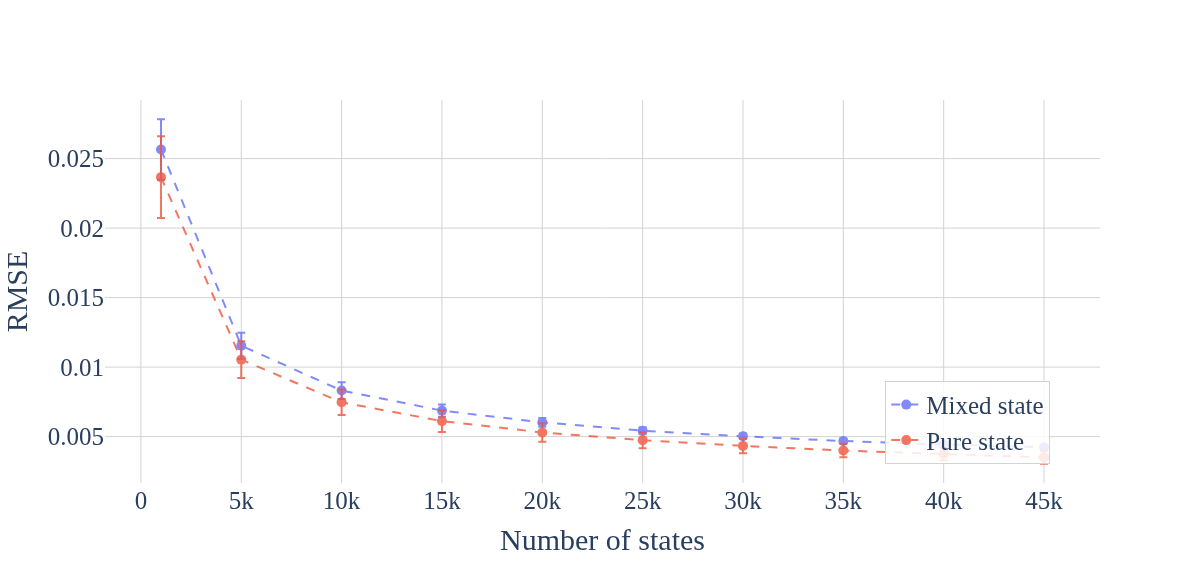

Combined error bar plot generated and saved to: RMSE_Analysis_Combined_ErrorBars.html


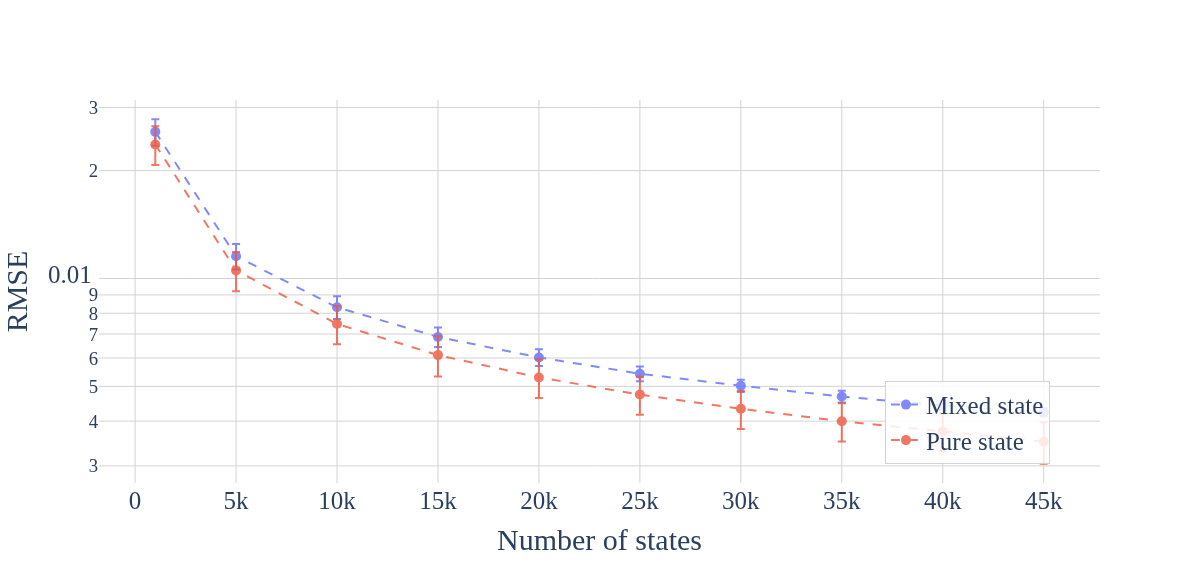

[None, None]

In [4]:
display([plotter(log_y_flag=False),plotter(log_y_flag=True)])

In [56]:
def plotter_inset():
    # =========================================================
    # 1. Aggregate Data (Calculate mean and std dev)
    # =========================================================
    df_noise_stats = df_noise.groupby("States")["RMSE"].agg(["mean", "std"]).reset_index()
    df_noise_stats["std"] = df_noise_stats["std"].fillna(0)
    
    df_noiseless_stats = df_noiseless.groupby("States")["RMSE"].agg(["mean", "std"]).reset_index()
    df_noiseless_stats["std"] = df_noiseless_stats["std"].fillna(0)

    color_noise = '#636EFA'
    color_noiseless = '#EF553B'

    # =========================================================
    # 2. Initialize Figure & Variables
    # =========================================================
    fig = go.Figure()
    opacity_value = 0.8

    # =========================================================
    # 3. Add MAIN Traces (Linear scale)
    # =========================================================
    fig.add_trace(go.Scatter(
        x=df_noise_stats["States"], y=df_noise_stats["mean"],
        error_y=dict(type='data', array=df_noise_stats["std"], visible=True),
        mode='lines+markers', name="Mixed state",
        marker=dict(size=10, color=color_noise), 
        opacity=opacity_value,
        line=dict(dash='dash', width=2, color=color_noise)
    ))

    fig.add_trace(go.Scatter(
        x=df_noiseless_stats["States"], y=df_noiseless_stats["mean"],
        error_y=dict(type='data', array=df_noiseless_stats["std"], visible=True),
        mode='lines+markers', name="Pure state",
        marker=dict(size=10, color=color_noiseless), 
        opacity=opacity_value,
        line=dict(dash='dash', width=2, color=color_noiseless)
    ))

    # =========================================================
    # 4. Add INSET Traces (Mapped to x2, y2)
    # =========================================================
    fig.add_trace(go.Scatter(
        x=df_noise_stats["States"], y=df_noise_stats["mean"],
        error_y=dict(type='data', array=df_noise_stats["std"], visible=True),
        mode='lines+markers', showlegend=False,
        xaxis='x2', yaxis='y2', 
        marker=dict(size=10, color=color_noise), 
        opacity=opacity_value,
        line=dict(dash='dash', width=2, color=color_noise)
    ))

    fig.add_trace(go.Scatter(
        x=df_noiseless_stats["States"], y=df_noiseless_stats["mean"],
        error_y=dict(type='data', array=df_noiseless_stats["std"], visible=True),
        mode='lines+markers', showlegend=False,
        xaxis='x2', yaxis='y2', 
        marker=dict(size=10, color=color_noiseless), 
        opacity=opacity_value,
        line=dict(dash='dash', width=2, color=color_noiseless)
    ))

    # =========================================================
    # 5. Update Layout (Main Axes, Inset Axes, Fonts, Sizes)
    # =========================================================
    fig.update_layout(
        width=1000,
        height=563, 
        plot_bgcolor='white',
        paper_bgcolor='white',
        
        legend=dict(
            font=dict(family="Times New Roman", size=20)
        ),
        
        # --- MAIN X-Axis ---
        xaxis=dict(
            title=dict(text="Number of states", font=dict(family="Times New Roman", size=25)), 
            tickfont=dict(family="Times New Roman", size=20), 
            showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=False,
            showline=True, linewidth=1, linecolor='gray', mirror=True
        ),
        
        # --- MAIN Y-Axis ---
        yaxis=dict(
            title=dict(text="RMSE", font=dict(family="Times New Roman", size=25)), 
            tickfont=dict(family="Times New Roman", size=20),
            showgrid=True, gridwidth=1, gridcolor='lightgray', zeroline=False,
            type='linear',
            showline=True, linewidth=1, linecolor='gray', mirror=True
        ),

        # --- INSET X-Axis (x2) ---
        xaxis2=dict(
            domain=[0.33, 0.95], 
            anchor='y2',
            range=[14000, 46000], 
            # Increased font size to 20
            tickfont=dict(family="Times New Roman", size=20),
            showgrid=True, gridcolor='lightgray',
            # Increased font size to 20
            title=dict(text="Zoom (15k-45k)", font=dict(family="Times New Roman", size=20)),
            showline=True, linewidth=1, linecolor='gray', mirror=True 
        ),
        
        # --- INSET Y-Axis (y2) ---
        yaxis2=dict(
            domain=[0.4, 0.96],  
            anchor='x2',
            type='log',
            range=[np.log10(3e-3), np.log10(8e-3)], 
            # Explicitly declare which ticks to show to prevent crowding
            tickvals=[0.003, 0.004, 0.005, 0.006, 0.007, 0.008], 
            # Increased font size to 20
            tickfont=dict(family="Times New Roman", size=20),
            showgrid=True, gridcolor='lightgray',
            showline=True, linewidth=1, linecolor='gray', mirror=True
        )
    )

    # =========================================================
    # 6. Export and Display
    # =========================================================
    output_html = "R2_Analysis_Inset_Framed_TicksFixed.html"
    output_vector = "RMSE_convergence.pdf"
    fig.write_image(output_vector)
    print(f"Plot with framed inset generated and saved to: {output_html}")
    
    fig.show()

Plot with framed inset generated and saved to: R2_Analysis_Inset_Framed_TicksFixed.html


/tmp/ipykernel_33585/3283102548.py:127: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




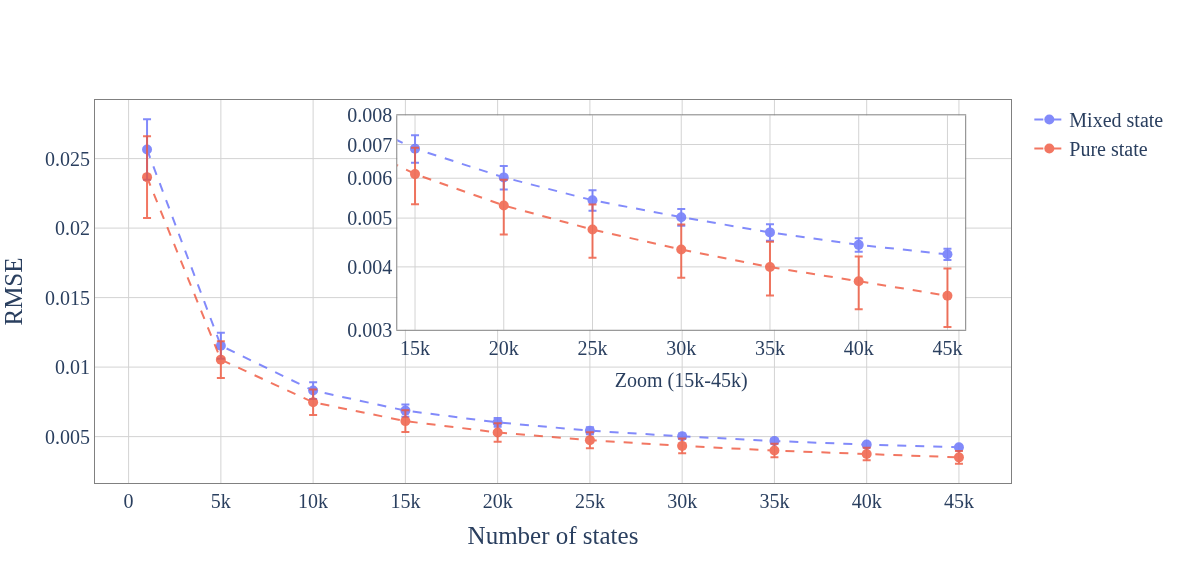

In [57]:
plotter_inset()